<a href="https://colab.research.google.com/github/lynnfdsouza/drone_terrain_masking/blob/main/sim_a2a_a2g_002_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import asyncio
import platform
import numpy as np
from dataclasses import dataclass
from typing import List, Tuple, Optional

import nest_asyncio
nest_asyncio.apply()

# ── Constants ────────────────────────────────────────────────────────────────
FPS = 60
EARTH_RADIUS = 6_371_000  # metres
MAX_SIM_TIME = 120.0      # seconds — hard cap (Bug 3 fix: was infinite loop)
M_PER_DEG_LAT = 111_000.0 # metres per degree latitude

# Bug F: weapons with computed hit-probability below this threshold are skipped in
# select_munition — prevents Hellfire (~3% hp at 10 km) silently burning rounds.
MIN_HIT_PROB = 0.10

# Weapon time-of-flight speeds used to set post-miss fire cooldowns.
WEAPON_SPEEDS: dict = {
    "AGM-114 Hellfire": 475.0,  # m/s
    "GBU-39B SDB II":   220.0,  # m/s (glide bomb — fire-and-forget)
    "Coyote Block 2":   250.0,  # m/s
    "APKWS Rocket":     900.0,  # m/s
}

# Fire-and-forget weapons use a short fixed delay instead of full TOF (Bug E fix).
FIRE_AND_FORGET = {"GBU-39B SDB II", "AGM-114 Hellfire"}
CONFIRM_MISS_DELAY = 2.0  # seconds


def m_per_deg_lon(lat_deg: float) -> float:
    return M_PER_DEG_LAT * np.cos(np.radians(lat_deg))


# ── Data classes ─────────────────────────────────────────────────────────────

@dataclass
class Munition:
    name: str
    type: str  # "air-to-ground" | "air-to-air"
    weight: float  # kg
    range: float   # metres
    cep: float     # Circular Error Probable (metres)
    warhead: float # kg explosive mass
    effectiveness: float = 1.0


@dataclass
class Target:
    id: int
    type: str  # "ground" | "air"
    position: np.ndarray  # [lat_deg, lon_deg, alt_m]
    velocity: np.ndarray  # [v_north, v_east, v_up] m/s
    priority: float       # 0–1
    is_active: bool = True


# ── Drone ─────────────────────────────────────────────────────────────────────

class Drone:
    def __init__(
        self,
        initial_position: np.ndarray,
        initial_velocity: np.ndarray,
        max_payload: float,
    ):
        self.position = initial_position.astype(float)
        self.velocity = initial_velocity.astype(float)  # m/s
        self.max_payload = max_payload
        self.current_payload = 0.0
        self.munitions: List[Tuple[int, Munition]] = []
        self.sensors = {
            "radar": {"range": 50_000, "fov": 120},
            "eo_ir": {"range": 15_000, "fov": 30},
        }

        # Bug B fix: per-instance dicts (was a class-level shared dict).
        self.reservations: dict = {}      # munition_name → reserved_count
        self.fire_cooldown: dict = {}     # target_id → earliest fire time (Bug D fix)
        self.no_ammo_silence: dict = {}   # target_id → next allowed print time (Bug G fix)

    # ── Movement — Bug 4 fix: m/s → degrees/step ────────────────────────────
    def step(self, dt: float = 1.0 / FPS) -> None:
        lat = self.position[0]
        self.position[0] += self.velocity[0] * dt / M_PER_DEG_LAT
        self.position[1] += self.velocity[1] * dt / m_per_deg_lon(lat)
        self.position[2] += self.velocity[2] * dt

    # ── Payload ──────────────────────────────────────────────────────────────
    def load_munitions(self, items: List[Tuple[int, Munition]]) -> None:
        total_weight = sum(cnt * m.weight for cnt, m in items)
        if self.current_payload + total_weight <= self.max_payload:
            self.munitions.extend(items)
            self.current_payload += total_weight
            print(f"Loaded. Payload: {self.current_payload:.0f} / {self.max_payload:.0f} kg")
        else:
            print(
                f"ERROR: Payload overflow "
                f"({self.current_payload + total_weight:.0f} > {self.max_payload:.0f} kg)"
            )

    # ── Geometry ─────────────────────────────────────────────────────────────
    def calculate_distance(self, pos: np.ndarray) -> float:
        lat1, lon1, alt1 = self.position
        lat2, lon2, alt2 = pos
        dlat = np.radians(lat2 - lat1)
        dlon = np.radians(lon2 - lon1)
        a = (
            np.sin(dlat / 2) ** 2
            + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2))
            * np.sin(dlon / 2) ** 2
        )
        ground = EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
        return float(np.sqrt(ground ** 2 + (alt2 - alt1) ** 2))

    def detect_targets(self, targets: List[Target]) -> List[Target]:
        sensor_range = max(s["range"] for s in self.sensors.values())
        return [
            t for t in targets
            if t.is_active and self.calculate_distance(t.position) <= sensor_range
        ]

    # ── Reservation helpers ──────────────────────────────────────────────────
    def available_count(self, munition: Munition) -> int:
        total = sum(cnt for cnt, m in self.munitions if m is munition)
        reserved = self.reservations.get(munition.name, 0)
        return max(0, total - reserved)

    def reserve(self, munition: Munition) -> None:
        self.reservations[munition.name] = self.reservations.get(munition.name, 0) + 1

    def consume_reservation(self, munition: Munition) -> None:
        if self.reservations.get(munition.name, 0) > 0:
            self.reservations[munition.name] -= 1

    # ── Munition selection ───────────────────────────────────────────────────
    def select_munition(
        self,
        target: Target,
        reserved_for: Optional[str] = None,
    ) -> Optional[Munition]:
        """
        Returns the highest-scoring munition for target, or None.

        Bug F fix: candidates whose hit-probability < MIN_HIT_PROB are rejected,
        preventing Hellfire (hp ≈ 3% at 10 km) from being selected as a backup.

        reserved_for: the munition name this target has a reservation on.
        The target may borrow that reserved round even if available_count == 0.
        """
        distance = self.calculate_distance(target.position)
        suitable: List[Tuple[float, Munition]] = []

        for cnt, munition in self.munitions:
            if cnt <= 0:
                continue
            avail = self.available_count(munition)
            if reserved_for == munition.name:
                avail += 1  # entitled to its own reservation
            if avail <= 0:
                continue

            type_match = (
                (target.type == "ground" and munition.type == "air-to-ground") or
                (target.type == "air" and munition.type == "air-to-air")
            )
            if not type_match or distance > munition.range:
                continue

            # Bug F: reject weapons below minimum useful hit probability
            base_acc = max(0.0, 1.0 - munition.cep / munition.range)
            range_factor = max(0.0, 1.0 - distance / munition.range)
            hit_prob = float(
                np.clip(base_acc * range_factor * munition.effectiveness, 0.0, 1.0)
            )
            if hit_prob < MIN_HIT_PROB:
                continue

            score = (
                munition.effectiveness
                * (1.0 - distance / munition.range * 0.5)
                * target.priority
            )
            suitable.append((score, munition))

        if not suitable:
            return None
        suitable.sort(key=lambda x: x[0], reverse=True)
        return suitable[0][1]

    # ── Firing — Bug 6 fix: corrected hit-probability formula ────────────────
    def fire_munition(self, target: Target, munition: Munition) -> bool:
        fired = False
        for i, (cnt, m) in enumerate(self.munitions):
            if m is munition and cnt > 0:
                self.munitions[i] = (cnt - 1, m)
                self.current_payload -= munition.weight
                fired = True
                break
        if not fired:
            print(f" [ERROR] {munition.name} stock is 0.")
            return False

        self.consume_reservation(munition)

        distance = self.calculate_distance(target.position)
        base_acc = max(0.0, 1.0 - munition.cep / munition.range)
        range_factor = max(0.0, 1.0 - distance / munition.range)
        hit_prob = float(
            np.clip(base_acc * range_factor * munition.effectiveness, 0.0, 1.0)
        )

        print(
            f" Firing {munition.name} → T{target.id} "
            f"hp={hit_prob:.2f} dist={distance/1000:.2f} km"
        )

        if np.random.random() < hit_prob:
            print(f" ✓ T{target.id} NEUTRALISED ({munition.warhead} kg warhead)")
            target.is_active = False
            return True
        print(f" ✗ Missed T{target.id}")
        return False


# ── Target movement — Bug 5 fix: was never called ───────────────────────────

def step_targets(targets: List[Target], dt: float = 1.0 / FPS) -> None:
    for t in targets:
        if t.is_active:
            lat = t.position[0]
            t.position[0] += t.velocity[0] * dt / M_PER_DEG_LAT
            t.position[1] += t.velocity[1] * dt / m_per_deg_lon(lat)
            t.position[2] += t.velocity[2] * dt


# ── Pre-assignment — Bug A / B / C fix ───────────────────────────────────────

def pre_assign_munitions(drone: Drone, detected: List[Target]) -> dict:
    """
    Called ONCE per frame before the firing loop (Bug A fix: was called inside
    the loop, resetting reservations on every iteration).

    Reserves exactly 1 round of the best useful weapon per active target, in
    descending priority order (Bug C fix: was only reserving for sole-option
    targets; T7 with 2 options received no reservation, so Coyotes were
    exhausted before T7 was reached).

    Bug B is fixed by using a per-instance reservations dict (see __init__).

    Returns {target_id → munition_name} so each target can borrow its slot in
    select_munition via reserved_for=.
    """
    drone.reservations.clear()
    reservation: dict = {}

    for target in sorted(detected, key=lambda t: t.priority, reverse=True):
        if not target.is_active:
            continue
        distance = drone.calculate_distance(target.position)
        best = None
        best_score = -1.0

        for cnt, munition in drone.munitions:
            if cnt <= 0 or drone.available_count(munition) <= 0:
                continue
            type_match = (
                (target.type == "ground" and munition.type == "air-to-ground") or
                (target.type == "air" and munition.type == "air-to-air")
            )
            if not type_match or distance > munition.range:
                continue
            # Mirror Bug F filter so reserved weapon is also one that will actually fire
            base_acc = max(0.0, 1.0 - munition.cep / munition.range)
            range_factor = max(0.0, 1.0 - distance / munition.range)
            if base_acc * range_factor * munition.effectiveness < MIN_HIT_PROB:
                continue
            score = (
                munition.effectiveness
                * (1.0 - distance / munition.range * 0.5)
                * target.priority
            )
            if score > best_score:
                best_score = score
                best = munition

        if best is not None:
            drone.reserve(best)
            reservation[target.id] = best.name

    return reservation


# ── Simulation loop ──────────────────────────────────────────────────────────

async def run_simulation():
    # ── Munition catalogue ───────────────────────────────────────────────────
    hellfire = Munition(
        "AGM-114 Hellfire", "air-to-ground",
        weight=49, range=11_000, cep=1.0, warhead=20, effectiveness=0.70
    )
    sdb2 = Munition(
        "GBU-39B SDB II", "air-to-ground",
        weight=200, range=110_000, cep=1.0, warhead=93, effectiveness=0.90
    )
    coyote = Munition(
        "Coyote Block 2", "air-to-air",
        weight=30, range=20_000, cep=2.0, warhead=5, effectiveness=0.75
    )
    apkws = Munition(
        "APKWS Rocket", "air-to-air",
        weight=15, range=12_000, cep=1.5, warhead=3, effectiveness=0.90
    )

    # ── Drone ────────────────────────────────────────────────────────────────
    drone = Drone(
        initial_position=np.array([0.0, 0.0, 10_000.0]),
        initial_velocity=np.array([83.33, 0.0, 0.0]),  # ~300 km/h north
        max_payload=3_500,  # increased for 8× SDB
    )

    drone.load_munitions([
        (4,  hellfire),  # backup A2G (only fires if within effective range, MIN_HIT_PROB filter)
        (8,  sdb2),      # primary A2G — was 4; +4 gives ~2.7 shots per ground target
        (6,  coyote),    # A2A — was 4; +2 re-engagement margin
        (12, apkws),     # A2A — was 8; +4 depth; range extended to 12 km to outscore Coyote at T7 distances
    ])

    # ── Targets ──────────────────────────────────────────────────────────────
    targets = [
        Target(1, "ground", np.array([ 0.010,  0.010,    0.0]), np.array([  0,   0, 0]), priority=0.90),
        Target(2, "air",    np.array([ 0.001,  0.001, 5000.0]), np.array([ 10,  10, 0]), priority=0.80),
        Target(3, "ground", np.array([-0.020,  0.030,  100.0]), np.array([ -5,   2, 0]), priority=0.70),
        # T3 vel was [5,-2] (fleeing SW); changed to [-5,2] so it stays in engagement range
        Target(4, "air",    np.array([ 0.015, -0.010, 7500.0]), np.array([ -5,  15, 0]), priority=0.95),
        Target(5, "ground", np.array([ 0.030,  0.005,   0.0]),  np.array([  0,   0, 0]), priority=0.60),
        Target(6, "air",    np.array([-0.010, -0.020, 6000.0]), np.array([ 12,  -8, 0]), priority=0.85),
        Target(7, "air",    np.array([ 0.025, -0.025, 4500.0]), np.array([ 10,  10, 0]), priority=0.75),
        # T7 vel was [-10,-10] (fleeing SW permanently OOB); changed to [+10,+10] (closing)
    ]

    drone_history: list = []
    targets_history: list = []

    print("=" * 60)
    print("A2A / A2G Drone Simulation — all bugs fixed")
    print("=" * 60)

    simulation_time = 0.0
    dt = 1.0 / FPS

    while any(t.is_active for t in targets) and simulation_time <= MAX_SIM_TIME:

        drone.step(dt)
        step_targets(targets, dt)

        drone_history.append({
            "time": simulation_time,
            "position": drone.position.copy(),
            "payload": drone.current_payload,
        })
        targets_history.append({
            "time": simulation_time,
            "targets": [
                {
                    "id": t.id,
                    "type": t.type,
                    "position": t.position.copy(),
                    "priority": t.priority,
                    "is_active": t.is_active,
                }
                for t in targets
            ],
        })

        detected = drone.detect_targets(targets)

        if not detected:
            if round(simulation_time * FPS) % (FPS * 5) == 0:
                print(f"[{simulation_time:.1f}s] No targets in sensor range.")
        else:
            # Bug A fix: pre-assign once per frame, BEFORE the firing loop.
            target_reservation = pre_assign_munitions(drone, detected)
            detected.sort(key=lambda t: t.priority, reverse=True)

            for target in detected:
                if not target.is_active:
                    continue

                # Bug D fix: per-target fire cooldown.
                if simulation_time < drone.fire_cooldown.get(target.id, 0.0):
                    continue

                munition = drone.select_munition(
                    target, reserved_for=target_reservation.get(target.id)
                )

                if munition:
                    drone.no_ammo_silence.pop(target.id, None)
                    print(
                        f"[{simulation_time:.2f}s] Engaging T{target.id} "
                        f"({target.type}) dist={drone.calculate_distance(target.position)/1000:.2f} km"
                    )
                    hit = drone.fire_munition(target, munition)
                    if not hit:
                        # Bug E fix: weapon-specific cooldown.
                        if munition.name in FIRE_AND_FORGET:
                            tof = CONFIRM_MISS_DELAY
                        else:
                            tof = (
                                drone.calculate_distance(target.position)
                                / WEAPON_SPEEDS.get(munition.name, 300.0)
                            )
                        drone.fire_cooldown[target.id] = simulation_time + max(tof, 0.5)
                else:
                    # Bug G fix: throttle "no suitable munition" to once per 10 s per target.
                    if simulation_time >= drone.no_ammo_silence.get(target.id, 0.0):
                        print(
                            f"[{simulation_time:.2f}s] No suitable munition for "
                            f"T{target.id} ({target.type})"
                        )
                        drone.no_ammo_silence[target.id] = simulation_time + 10.0

        simulation_time += dt
        # Bug 7 fix: asyncio.sleep removed

    # ── Summary ───────────────────────────────────────────────────────────────
    print()
    print("=" * 60)
    reason = "time limit reached" if simulation_time > MAX_SIM_TIME else "all targets neutralised"
    print(f"Simulation ended : {reason}")
    print(f"Total time : {simulation_time:.2f} s")
    print(f"Remaining payload : {drone.current_payload:.0f} kg")
    neutralised = sum(1 for t in targets if not t.is_active)
    print(f"Targets killed : {neutralised} / {len(targets)}")
    for t in targets:
        status = "KILLED " if not t.is_active else "SURVIVED"
        print(f" T{t.id} ({t.type:6s}) pri={t.priority} [{status}]")
    print("=" * 60)

    return drone_history, targets_history


# ── Entry point (Colab / Jupyter safe) ───────────────────────────────────────

def run_and_export():
    """Helper for Colab: runs sim, returns histories, and exports CSVs."""
    import pandas as pd

    loop = asyncio.get_event_loop()
    drone_history_data, targets_history_data = loop.run_until_complete(run_simulation())

    # Flatten and export histories
    drone_rows = []
    for rec in drone_history_data:
        time = rec["time"]
        lat, lon, alt = rec["position"]
        payload = rec["payload"]
        drone_rows.append(
            {"time": time, "lat": lat, "lon": lon, "alt": alt, "payload": payload}
        )

    target_rows = []
    for rec in targets_history_data:
        time = rec["time"]
        for t in rec["targets"]:
            lat, lon, alt = t["position"]
            target_rows.append(
                {
                    "time": time,
                    "id": t["id"],
                    "type": t["type"],
                    "lat": lat,
                    "lon": lon,
                    "alt": alt,
                    "priority": t["priority"],
                    "is_active": t["is_active"],
                }
            )

    pd.DataFrame(drone_rows).to_csv("drone_history.csv", index=False)
    pd.DataFrame(target_rows).to_csv("targets_history.csv", index=False)
    print("Histories exported: drone_history.csv, targets_history.csv")

    return drone_history_data, targets_history_data


if __name__ == "__main__":
    try:
        run_and_export()
    except KeyboardInterrupt:
        print("\nSimulation interrupted.")


Loaded. Payload: 2156 / 3500 kg
A2A / A2G Drone Simulation — all bugs fixed
[0.00s] Engaging T4 (air) dist=3.20 km
 Firing APKWS Rocket → T4 hp=0.66 dist=3.20 km
 ✗ Missed T4
[0.00s] Engaging T1 (ground) dist=10.12 km
 Firing GBU-39B SDB II → T1 hp=0.82 dist=10.12 km
 ✓ T1 NEUTRALISED (93 kg warhead)
[0.00s] Engaging T6 (air) dist=4.71 km
 Firing APKWS Rocket → T6 hp=0.55 dist=4.71 km
 ✗ Missed T6
[0.00s] Engaging T2 (air) dist=5.00 km
 Firing APKWS Rocket → T2 hp=0.52 dist=5.00 km
 ✗ Missed T2
[0.00s] Engaging T7 (air) dist=6.76 km
 Firing APKWS Rocket → T7 hp=0.39 dist=6.76 km
 ✗ Missed T7
[0.00s] Engaging T3 (ground) dist=10.68 km
 Firing GBU-39B SDB II → T3 hp=0.81 dist=10.68 km
 ✓ T3 NEUTRALISED (93 kg warhead)
[0.00s] Engaging T5 (ground) dist=10.56 km
 Firing GBU-39B SDB II → T5 hp=0.81 dist=10.56 km
 ✗ Missed T5
[2.02s] Engaging T5 (ground) dist=10.50 km
 Firing GBU-39B SDB II → T5 hp=0.81 dist=10.50 km
 ✓ T5 NEUTRALISED (93 kg warhead)
[3.57s] Engaging T4 (air) dist=3.03 km
 F

In [8]:
# Display summary statistics for targets_df
display(targets_df.describe())

,time,id,lat,lon,alt,priority
count,12054.000000,12054.000000,12054.000000,12054.000000,12054.000000,12054.000000
mean,14.341667,4.000000,0.007648,-0.001060,3300.000000,0.792857
std,8.285319,2.000083,0.016850,0.017315,2958.886958,0.111580
min,0.000000,1.000000,-0.020001,-0.024998,0.000000,0.600000
25%,7.166667,2.000000,-0.008849,-0.020517,0.000000,0.700000
50%,14.341667,4.000000,0.010000,0.001503,4500.000000,0.800000
75%,21.516667,6.000000,0.025647,0.010000,6000.000000,0.900000
max,28.683333,7.000000,0.030000,0.030000,7500.000000,0.950000


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the targets history data
targets_df = pd.read_csv('targets_history.csv')

# Display the first few rows and information about the DataFrame
print('Targets History DataFrame Head:')
display(targets_df.head())
print('\nTargets History DataFrame Info:')
targets_df.info()

Targets History DataFrame Head:


,time,id,type,lat,lon,alt,priority,is_active
0,0.0,1,ground,0.010000,0.010000,0.0,0.90,True
1,0.0,2,air,0.001002,0.001002,5000.0,0.80,True
2,0.0,3,ground,-0.020001,0.030000,100.0,0.70,True
3,0.0,4,air,0.014999,-0.009998,7500.0,0.95,True
4,0.0,5,ground,0.030000,0.005000,0.0,0.60,True



Targets History DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12054 entries, 0 to 12053
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   time       12054 non-null  float64
 1   id         12054 non-null  int64  
 2   type       12054 non-null  object 
 3   lat        12054 non-null  float64
 4   lon        12054 non-null  float64
 5   alt        12054 non-null  float64
 6   priority   12054 non-null  float64
 7   is_active  12054 non-null  bool   
dtypes: bool(1), float64(5), int64(1), object(1)
memory usage: 671.1+ KB


Now, let's visualize the trajectories of the targets over time. We'll create a 2D plot showing latitude and longitude, and another plot showing altitude over time for air targets. We'll also visualize when each target becomes inactive.

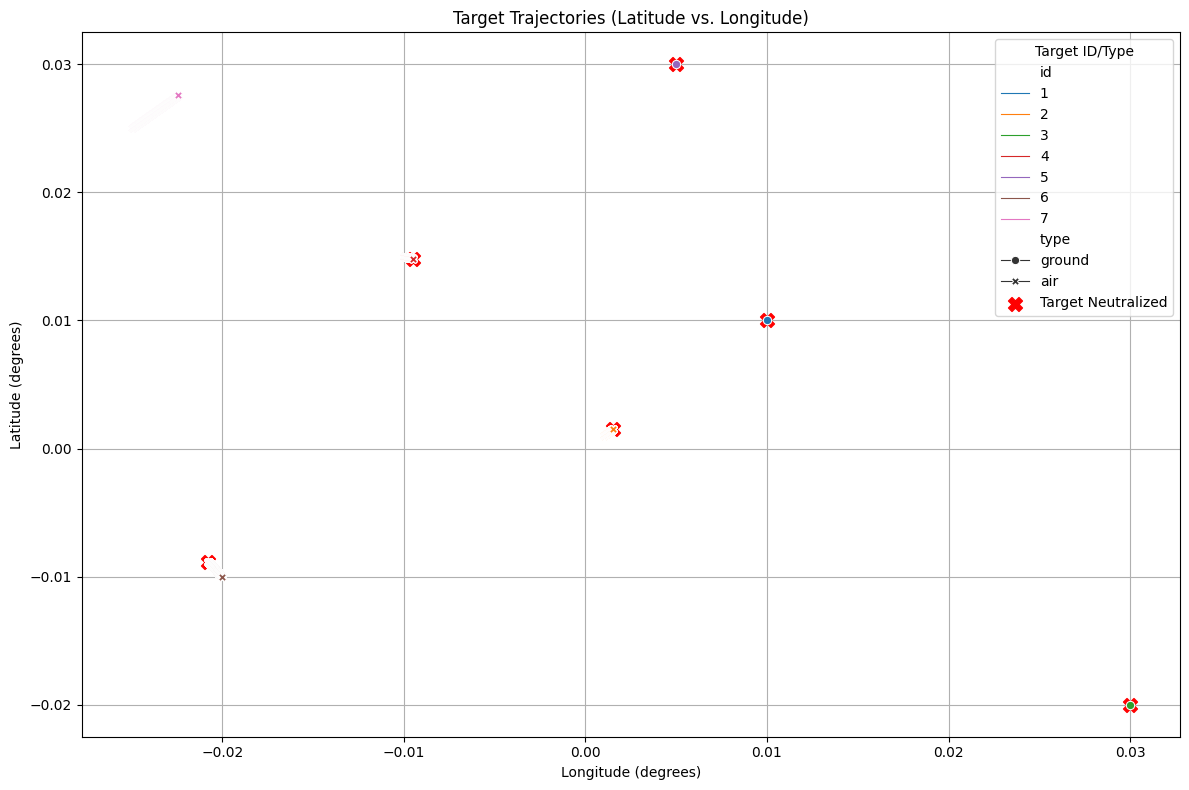

In [4]:
# Plotting 2D trajectories (Latitude vs. Longitude)
plt.figure(figsize=(12, 8))
sns.lineplot(
    data=targets_df,
    x='lon',
    y='lat',
    hue='id',
    style='type',
    markers=True,
    dashes=False,
    palette='tab10',
    linewidth=0.8
)

# Mark the points where targets become inactive
inactive_targets = targets_df[~targets_df['is_active']].groupby('id').first().reset_index()
plt.scatter(
    inactive_targets['lon'],
    inactive_targets['lat'],
    color='red',
    marker='X',
    s=100,
    label='Target Neutralized'
)

plt.title('Target Trajectories (Latitude vs. Longitude)')
plt.xlabel('Longitude (degrees)')
plt.ylabel('Latitude (degrees)')
plt.grid(True)
plt.legend(title='Target ID/Type')
plt.tight_layout()
plt.show()

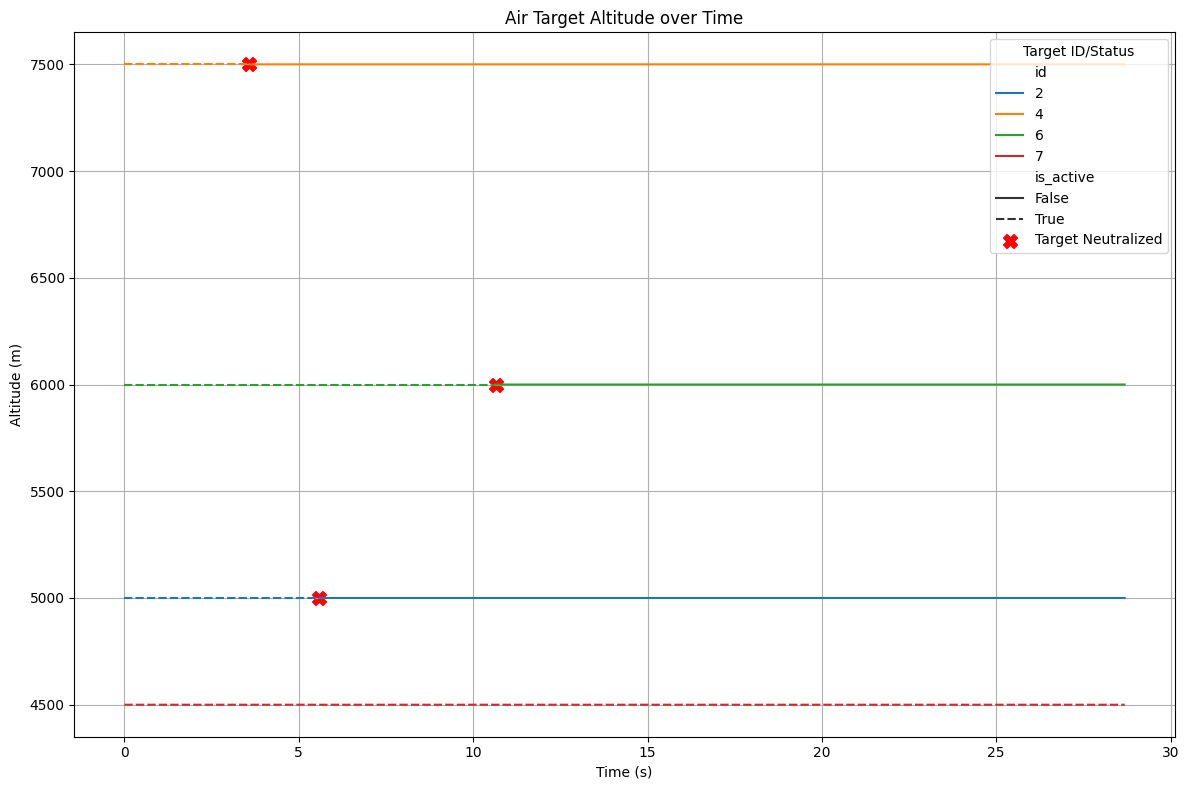

In [5]:
# Plotting Altitude over Time for Air Targets
air_targets_df = targets_df[targets_df['type'] == 'air']

plt.figure(figsize=(12, 8))
sns.lineplot(
    data=air_targets_df,
    x='time',
    y='alt',
    hue='id',
    style='is_active',
    markers=False,
    dashes=True,
    palette='tab10',
    linewidth=1.5
)

# Mark the points where air targets become inactive
inactive_air_targets = air_targets_df[~air_targets_df['is_active']].groupby('id').first().reset_index()
plt.scatter(
    inactive_air_targets['time'],
    inactive_air_targets['alt'],
    color='red',
    marker='X',
    s=100,
    label='Target Neutralized'
)

plt.title('Air Target Altitude over Time')
plt.xlabel('Time (s)')
plt.ylabel('Altitude (m)')
plt.grid(True)
plt.legend(title='Target ID/Status')
plt.tight_layout()
plt.show()

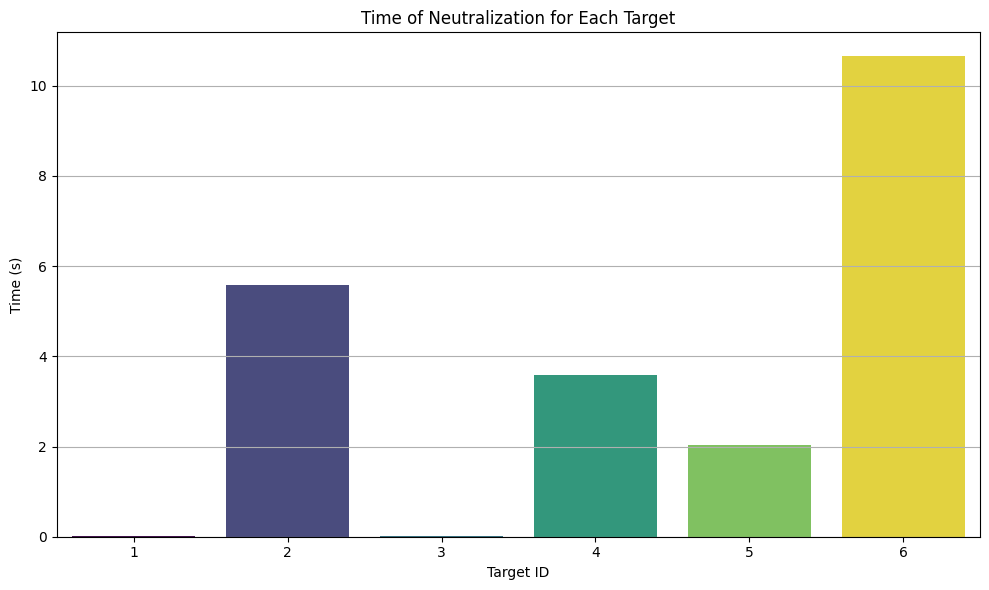

In [7]:
# Visualize when targets become inactive
neutralization_times = targets_df[~targets_df['is_active']].groupby('id')['time'].min().reset_index()
neutralization_times.columns = ['Target ID', 'Neutralization Time (s)']

if not neutralization_times.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=neutralization_times.sort_values(by='Neutralization Time (s)'),
        x='Target ID',
        y='Neutralization Time (s)',
        hue='Target ID', # Added to address FutureWarning
        palette='viridis',
        legend=False # Added because hue is now explicitly set
    )
    plt.title('Time of Neutralization for Each Target')
    plt.xlabel('Target ID')
    plt.ylabel('Time (s)')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()
else:
    print("All targets remained active throughout the simulation.")

Here are the summary statistics for your targets_df DataFrame:

time: The simulation ran for approximately 28.68 seconds, with data points collected throughout this period.
id: There are 7 unique targets in the simulation (from 1 to 7).
lat and lon: These show the geographical spread of the targets. The mean latitude is around 0.007 degrees and longitude around -0.001 degrees, indicating targets generally stayed near the origin. The standard deviation and min/max values give insight into their movement range.
alt: The altitude ranges from 0m (ground targets) to 7500m (air targets), with an average of 3300m across all data points.
priority: Target priorities range from 0.60 to 0.95, with an average of approximately 0.79. This confirms the varying importance assigned to different targets in the simulation.
These statistics give a good overview of the numerical data within the targets_df, including the spread and central tendencies of target positions, time, and priority.